<a href="https://colab.research.google.com/github/omerfarukt61/DIA/blob/main/DIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_auc_score, f1_score, precision_score, recall_score,
    matthews_corrcoef, roc_curve, precision_recall_curve, auc
)
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})
print("Tüm kütüphaneler yüklendi.")

Tüm kütüphaneler yüklendi.


In [ ]:
train_df = pd.read_csv('DIA_trainingset_RDKit_descriptors.csv')
test_df  = pd.read_csv('DIA_testset_RDKit_descriptors.csv')

y_train_orig = train_df['Label']
y_test       = test_df['Label']
X_train_orig = train_df.drop(columns=['Label', 'SMILES'])
X_test       = test_df.drop(columns=['Label', 'SMILES'])

print("=" * 50)
print(f"Eğitim seti : {X_train_orig.shape[0]} örnek, {X_train_orig.shape[1]} özellik")
print(f"Test seti   : {X_test.shape[0]} örnek")
print()
vc = y_train_orig.value_counts()
ratio = vc[0] / vc[1]
print(f"Sınıf 0 (Negatif): {vc[0]}  |  Sınıf 1 (Pozitif): {vc[1]}")
print(f"Dengesizlik oranı : {ratio:.2f}:1  ← 3:1 dengesizlik!")
print("=" * 50)

Eğitim seti : 477 örnek, 196 özellik
Test seti   : 120 örnek

Sınıf 0 (Negatif): 359  |  Sınıf 1 (Pozitif): 118
Dengesizlik oranı : 3.04:1  ← 3:1 dengesizlik!


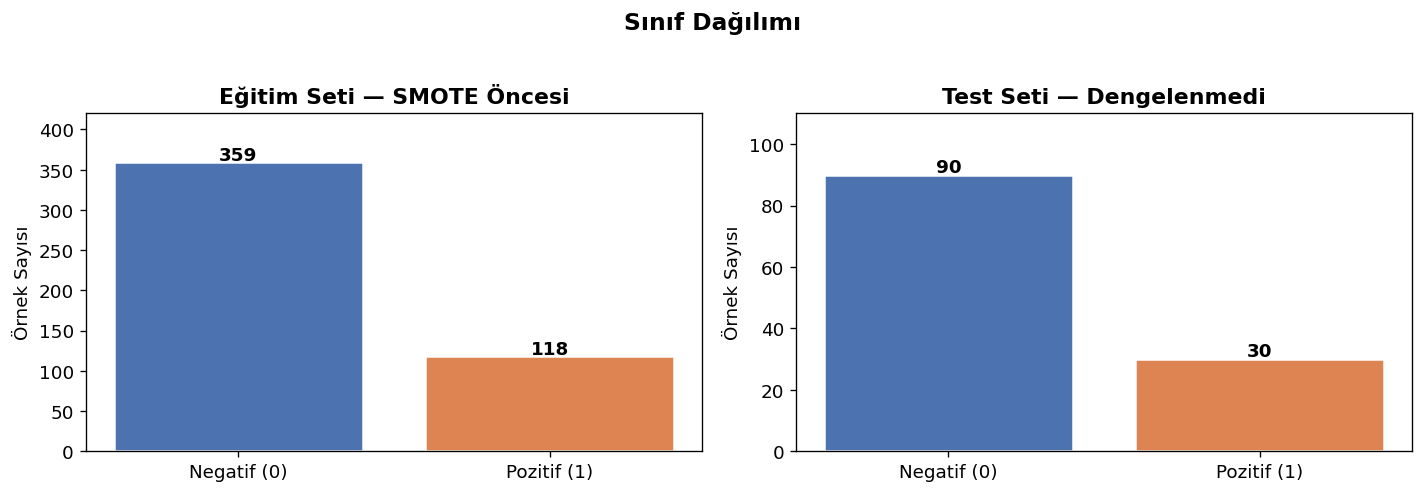

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Eğitim seti
vc_train = y_train_orig.value_counts()
bars0 = axes[0].bar(['Negatif (0)', 'Pozitif (1)'], vc_train.values,
                     color=['#4C72B0', '#DD8452'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Eğitim Seti — SMOTE Öncesi', fontweight='bold')
axes[0].set_ylabel('Örnek Sayısı')
for bar, val in zip(bars0, vc_train.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 f'{val}', ha='center', fontweight='bold')
axes[0].set_ylim(0, 420)

# Test seti
vc_test = y_test.value_counts()
bars1 = axes[1].bar(['Negatif (0)', 'Pozitif (1)'], vc_test.values,
                     color=['#4C72B0', '#DD8452'], edgecolor='white', linewidth=1.5)
axes[1].set_title('Test Seti — Dengelenmedi', fontweight='bold')
axes[1].set_ylabel('Örnek Sayısı')
for bar, val in zip(bars1, vc_test.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val}', ha='center', fontweight='bold')
axes[1].set_ylim(0, 110)

plt.suptitle('Sınıf Dağılımı', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

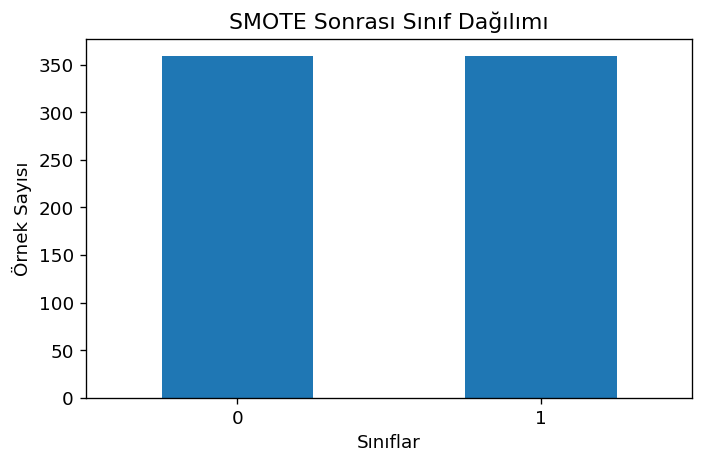

In [ ]:
# SMOTE sonrası sınıf dağılımı grafiği
import matplotlib.pyplot as plt
import pandas as pd
from imblearn.over_sampling import SMOTE # Import SMOTE

# SMOTE uygulaması
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_orig, y_train_orig)

# SMOTE sonrası hedef değişken dağılımı
smote_counts = pd.Series(y_train_bal).value_counts()

plt.figure(figsize=(6,4))
smote_counts.plot(kind='bar')
plt.title('SMOTE Sonrası Sınıf Dağılımı')
plt.xlabel('Sınıflar')
plt.ylabel('Örnek Sayısı')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

# For CNN, we need to reshape the data to include a channel dimension
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print("Veriler ölçeklendi ve CNN için yeniden şekillendirildi.")

sonuclar = {}   # {model_adı: {'y_pred': ..., 'y_prob': ...}}

# 1. K-Means
print("1/9 K-Means...")
km = KMeans(n_clusters=2, random_state=42).fit(X_test_scaled)
yp = km.labels_
if accuracy_score(y_test, yp) < 0.5:
    yp = 1 - yp
sonuclar['K-Means'] = {'y_pred': yp, 'y_prob': None}

# 2. Lineer Regresyon
print("2/9 Lineer Regresyon...")
lr = LinearRegression().fit(X_train_scaled, y_train_bal)
yp = (lr.predict(X_test_scaled) >= 0.5).astype(int)
yprob = np.clip(lr.predict(X_test_scaled), 0, 1)
sonuclar['Lin. Regresyon'] = {'y_pred': yp, 'y_prob': yprob}

# 3. Naive Bayes
print("3/9 Naive Bayes...")
nb = GaussianNB().fit(X_train_scaled, y_train_bal)
yp = nb.predict(X_test_scaled)
sonuclar['Naive Bayes'] = {'y_pred': yp, 'y_prob': nb.predict_proba(X_test_scaled)[:,1]}

# 4. KNN
print("4/9 KNN...")
knn = KNeighborsClassifier(n_neighbors=5).fit(X_train_scaled, y_train_bal)
yp = knn.predict(X_test_scaled)
sonuclar['KNN'] = {'y_pred': yp, 'y_prob': knn.predict_proba(X_test_scaled)[:,1]}

# 5. SVM
print("5/9 SVM...")
svm = SVC(kernel='rbf', probability=True, random_state=42).fit(X_train_scaled, y_train_bal)
yp = svm.predict(X_test_scaled)
sonuclar['SVM'] = {'y_pred': yp, 'y_prob': svm.predict_proba(X_test_scaled)[:,1]}

# 6. Karar Ağacı
print("6/9 Karar Ağacı...")
dt = DecisionTreeClassifier(random_state=42).fit(X_train_scaled, y_train_bal)
yp = dt.predict(X_test_scaled)
sonuclar['Karar Ağacı'] = {'y_pred': yp, 'y_prob': dt.predict_proba(X_test_scaled)[:,1]}

# 7. Random Forest
print("7/9 Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_scaled, y_train_bal)
yp = rf.predict(X_test_scaled)
sonuclar['Random Forest'] = {'y_pred': yp, 'y_prob': rf.predict_proba(X_test_scaled)[:,1]}

# 8. YSA (MLP)
print("8/9 YSA (MLP)...")
mlp = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42).fit(X_train_scaled, y_train_bal)
yp = mlp.predict(X_test_scaled)
sonuclar['YSA (MLP)'] = {'y_pred': yp, 'y_prob': mlp.predict_proba(X_test_scaled)[:,1]}

# 9. CNN
print("9/9 CNN...")
cnn = Sequential([
    Conv1D(32, 3, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    MaxPooling1D(2),
    Flatten(),
    Dense(50, activation='relu'),
    Dense(1, activation='sigmoid')
])
cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn.fit(X_train_cnn, y_train_bal, epochs=20, batch_size=32, verbose=0)
y_prob_cnn = cnn.predict(X_test_cnn, verbose=0).flatten()
yp = (y_prob_cnn > 0.5).astype(int)
sonuclar['CNN'] = {'y_pred': yp, 'y_prob': y_prob_cnn}

print("\nTüm modeller tamamlandı!")

Veriler ölçeklendi ve CNN için yeniden şekillendirildi.
1/9 K-Means...
2/9 Lineer Regresyon...
3/9 Naive Bayes...
4/9 KNN...
5/9 SVM...
6/9 Karar Ağacı...
7/9 Random Forest...
8/9 YSA (MLP)...
9/9 CNN...

Tüm modeller tamamlandı!


In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.ensemble import GradientBoostingClassifier

# Calculate feature importances for Random Forest
fi_rf = pd.Series(rf.feature_importances_, index=X_train_orig.columns)

# Calculate permutation importance for Random Forest
perm_imp_rf = permutation_importance(rf, X_test_scaled, y_test, scoring='f1', random_state=42, n_repeats=5)
fi_perm = pd.Series(perm_imp_rf.importances_mean, index=X_train_orig.columns)

# Train Gradient Boosting Classifier and get importances
gb = GradientBoostingClassifier(n_estimators=100, random_state=42).fit(X_train_scaled, y_train_bal)
fi_gb = pd.Series(gb.feature_importances_, index=X_train_orig.columns)

# For Linear Regression, use absolute coefficients
# Note: The previous cell trained a LinearRegression, not LogisticRegression.
# Using absolute coefficients for feature importance from LinearRegression.
fi_lr = pd.Series(np.abs(lr.coef_), index=X_train_orig.columns)


# Normalize and Rank importances
def get_ranked_features(importance_series):
    # Higher importance value implies lower rank (more important)
    return importance_series.rank(ascending=False).sort_values(ascending=True)

rank_rf = get_ranked_features(fi_rf)
rank_perm = get_ranked_features(fi_perm)
rank_gb = get_ranked_features(fi_gb)
rank_lr = get_ranked_features(fi_lr)

# Combine ranks and find consensus top 10
combined_ranks = pd.DataFrame({
    'RF_Rank': rank_rf,
    'Perm_Rank': rank_perm,
    'GB_Rank': rank_gb,
    'LR_Rank': rank_lr
}).fillna(len(X_train_orig.columns) + 1) # Fill NaN ranks with a rank lower than any actual rank

# Calculate average rank
average_rank = combined_ranks.mean(axis=1).sort_values()

# Select top 10 features based on average rank
top10_features = average_rank.head(10).index.tolist()
top10_consensus = average_rank.loc[top10_features]

# Create top_rf, top_perm, top_gb, top_lr for plotting in subsequent cells
top_rf   = fi_rf.loc[top10_features].sort_values(ascending=True)
top_perm = fi_perm.loc[top10_features].sort_values(ascending=True)
top_gb   = fi_gb.loc[top10_features].sort_values(ascending=True)
top_lr   = fi_lr.loc[top10_features].sort_values(ascending=True)

print("Özellik önemleri hesaplandı ve ilk 10 özellik belirlendi.")

Özellik önemleri hesaplandı ve ilk 10 özellik belirlendi.


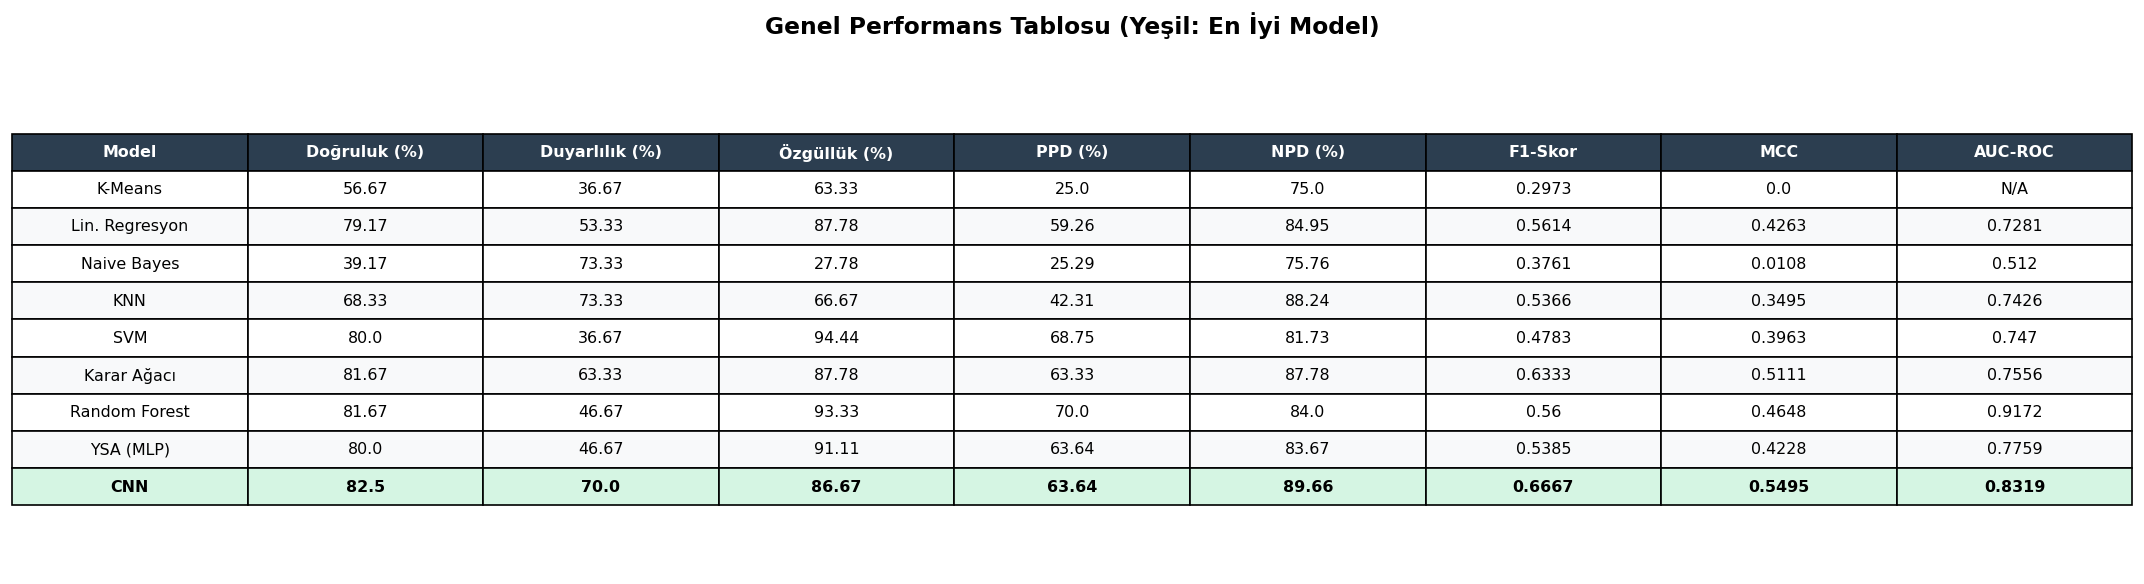


Tablo (sayısal):
         Model  Doğruluk (%)  Duyarlılık (%)  Özgüllük (%)  PPD (%)  NPD (%)  F1-Skor    MCC AUC-ROC
       K-Means         56.67           36.67         63.33    25.00    75.00   0.2973 0.0000     N/A
Lin. Regresyon         79.17           53.33         87.78    59.26    84.95   0.5614 0.4263  0.7281
   Naive Bayes         39.17           73.33         27.78    25.29    75.76   0.3761 0.0108   0.512
           KNN         68.33           73.33         66.67    42.31    88.24   0.5366 0.3495  0.7426
           SVM         80.00           36.67         94.44    68.75    81.73   0.4783 0.3963   0.747
   Karar Ağacı         81.67           63.33         87.78    63.33    87.78   0.6333 0.5111  0.7556
 Random Forest         81.67           46.67         93.33    70.00    84.00   0.5600 0.4648  0.9172
     YSA (MLP)         80.00           46.67         91.11    63.64    83.67   0.5385 0.4228  0.7759
           CNN         82.50           70.00         86.67    63.64    89

In [ ]:
satirlar = []
for isim, res in sonuclar.items():
    yp = res['y_pred']
    yprob = res['y_prob']
    cm = confusion_matrix(y_test, yp)
    tn, fp, fn, tp = cm.ravel()

    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv  = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv  = tn / (tn + fn) if (tn + fn) > 0 else 0
    f1   = f1_score(y_test, yp, zero_division=0)
    mcc  = matthews_corrcoef(y_test, yp)
    auc_roc = roc_auc_score(y_test, yprob) if yprob is not None else np.nan
    acc  = accuracy_score(y_test, yp)

    satirlar.append({
        'Model': isim, 'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
        'Doğruluk (%)': round(acc * 100, 2),
        'Duyarlılık (%)': round(sens * 100, 2),
        'Özgüllük (%)': round(spec * 100, 2),
        'PPD (%)': round(ppv * 100, 2),
        'NPD (%)': round(npv * 100, 2),
        'F1-Skor': round(f1, 4),
        'MCC': round(mcc, 4),
        'AUC-ROC': round(auc_roc, 4) if not np.isnan(auc_roc) else 'N/A'
    })

metrik_df = pd.DataFrame(satirlar)

# Renkli tablo
fig, ax = plt.subplots(figsize=(18, 5))
ax.axis('off')

tablo_cols = ['Model', 'Doğruluk (%)', 'Duyarlılık (%)', 'Özgüllük (%)',
              'PPD (%)', 'NPD (%)', 'F1-Skor', 'MCC', 'AUC-ROC']
tablo_data = metrik_df[tablo_cols].values.tolist()

tbl = ax.table(
    cellText=tablo_data,
    colLabels=tablo_cols,
    loc='center',
    cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1, 1.7)

# Başlık satırı renklendirme
for j in range(len(tablo_cols)):
    tbl[(0, j)].set_facecolor('#2C3E50')
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')

# En iyi model vurgusu (Doğruluk'a göre)
acc_vals = [float(r[1]) for r in tablo_data]
best_row = acc_vals.index(max(acc_vals)) + 1
for j in range(len(tablo_cols)):
    tbl[(best_row, j)].set_facecolor('#D5F5E3')
    tbl[(best_row, j)].set_text_props(fontweight='bold')

# Alternatif satır rengi
for i in range(1, len(tablo_data) + 1):
    if i != best_row:
        color = '#F8F9FA' if i % 2 == 0 else 'white'
        for j in range(len(tablo_cols)):
            tbl[(i, j)].set_facecolor(color)

plt.title('Genel Performans Tablosu (Yeşil: En İyi Model)',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nTablo (sayısal):")
print(metrik_df[tablo_cols].to_string(index=False))

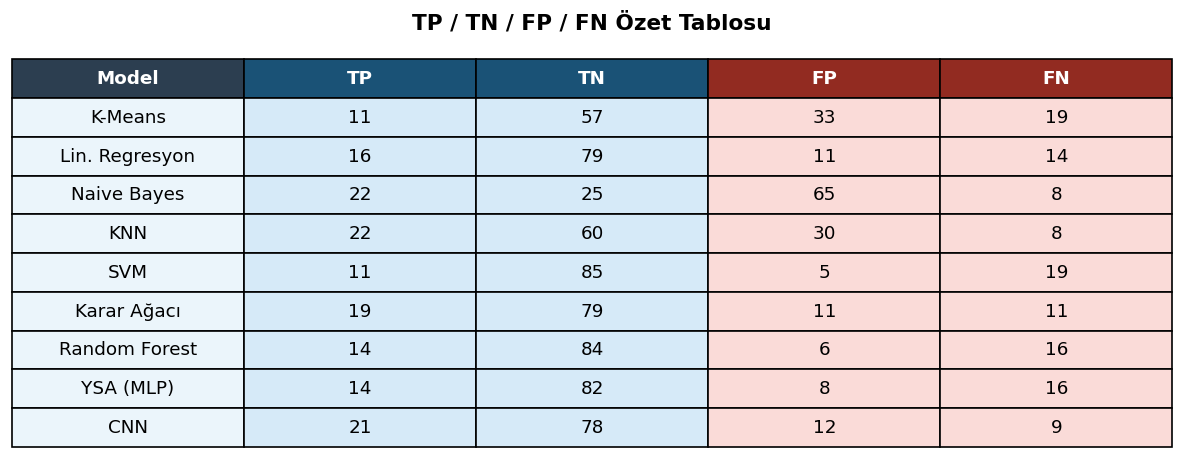

In [ ]:
cm_cols = ['Model', 'TP', 'TN', 'FP', 'FN']
cm_data = metrik_df[cm_cols].values.tolist()

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

tbl2 = ax.table(cellText=cm_data, colLabels=cm_cols, loc='center', cellLoc='center')
tbl2.auto_set_font_size(False)
tbl2.set_fontsize(11)
tbl2.scale(1, 1.8)

header_colors = {'Model': '#2C3E50', 'TP': '#1A5276', 'TN': '#1A5276',
                 'FP': '#922B21', 'FN': '#922B21'}
for j, col in enumerate(cm_cols):
    tbl2[(0, j)].set_facecolor(header_colors[col])
    tbl2[(0, j)].set_text_props(color='white', fontweight='bold')

for i in range(1, len(cm_data) + 1):
    tbl2[(i, 0)].set_facecolor('#EBF5FB')
    for j, col in enumerate(cm_cols[1:], start=1):
        if col in ['TP', 'TN']:
            tbl2[(i, j)].set_facecolor('#D6EAF8')
        else:
            tbl2[(i, j)].set_facecolor('#FADBD8')

plt.title('TP / TN / FP / FN Özet Tablosu', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

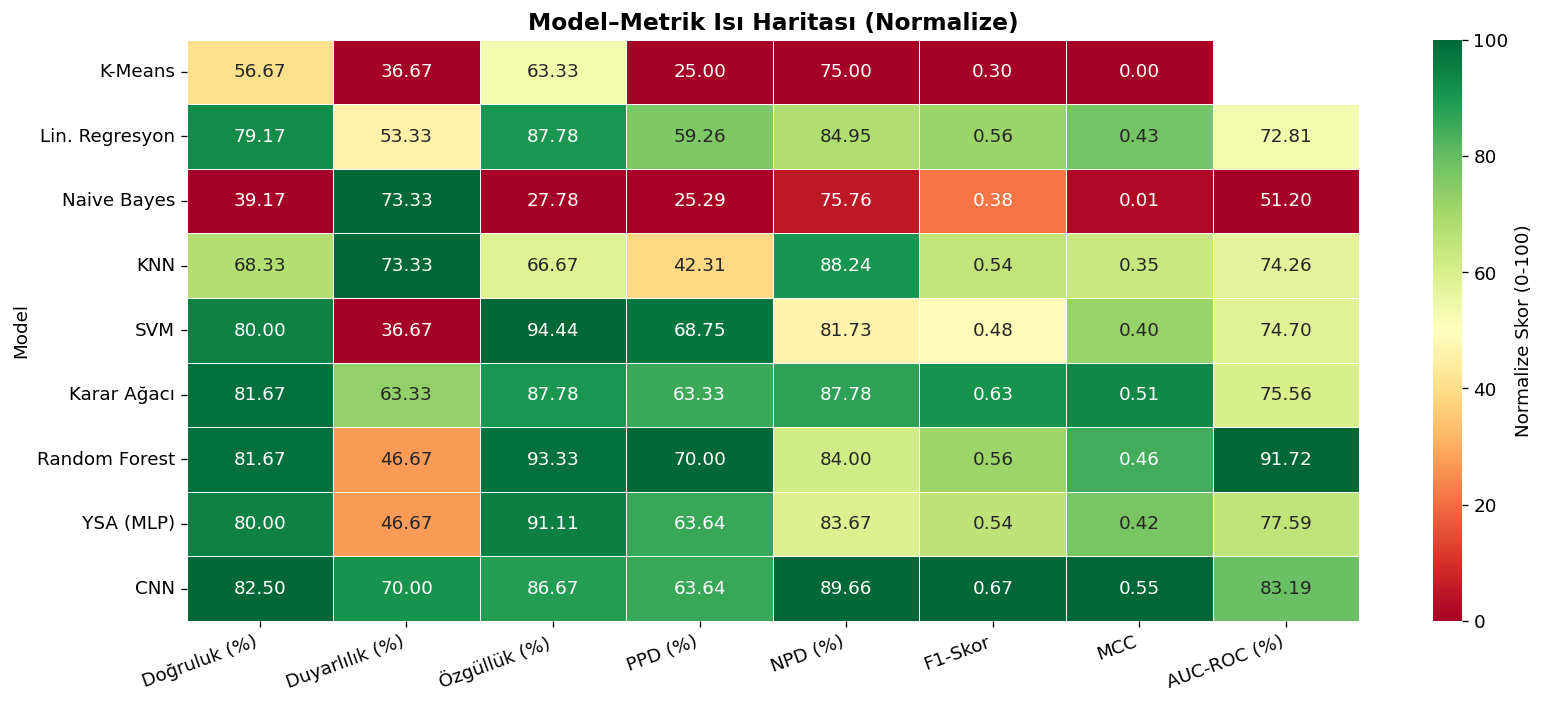

In [ ]:
isi_cols = ['Doğruluk (%)', 'Duyarlılık (%)', 'Özgüllük (%)', 'PPD (%)', 'NPD (%)', 'F1-Skor', 'MCC']
isi_df = metrik_df.set_index('Model')[isi_cols].copy()

# AUC'yi ekle (str değerleri NaN yap)
auc_vals = []
for v in metrik_df['AUC-ROC']:
    try:
        auc_vals.append(float(v) * 100)
    except:
        auc_vals.append(np.nan)
isi_df['AUC-ROC (%)'] = auc_vals

# 0-100 normalize
isi_norm = isi_df.copy()
for col in isi_df.columns:
    col_min, col_max = isi_df[col].min(), isi_df[col].max()
    if col_max != col_min:
        isi_norm[col] = (isi_df[col] - col_min) / (col_max - col_min) * 100

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(isi_norm, annot=isi_df.round(2), fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Normalize Skor (0-100)'})
ax.set_title('Model–Metrik Isı Haritası (Normalize)', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
plt.tight_layout()
plt.show()

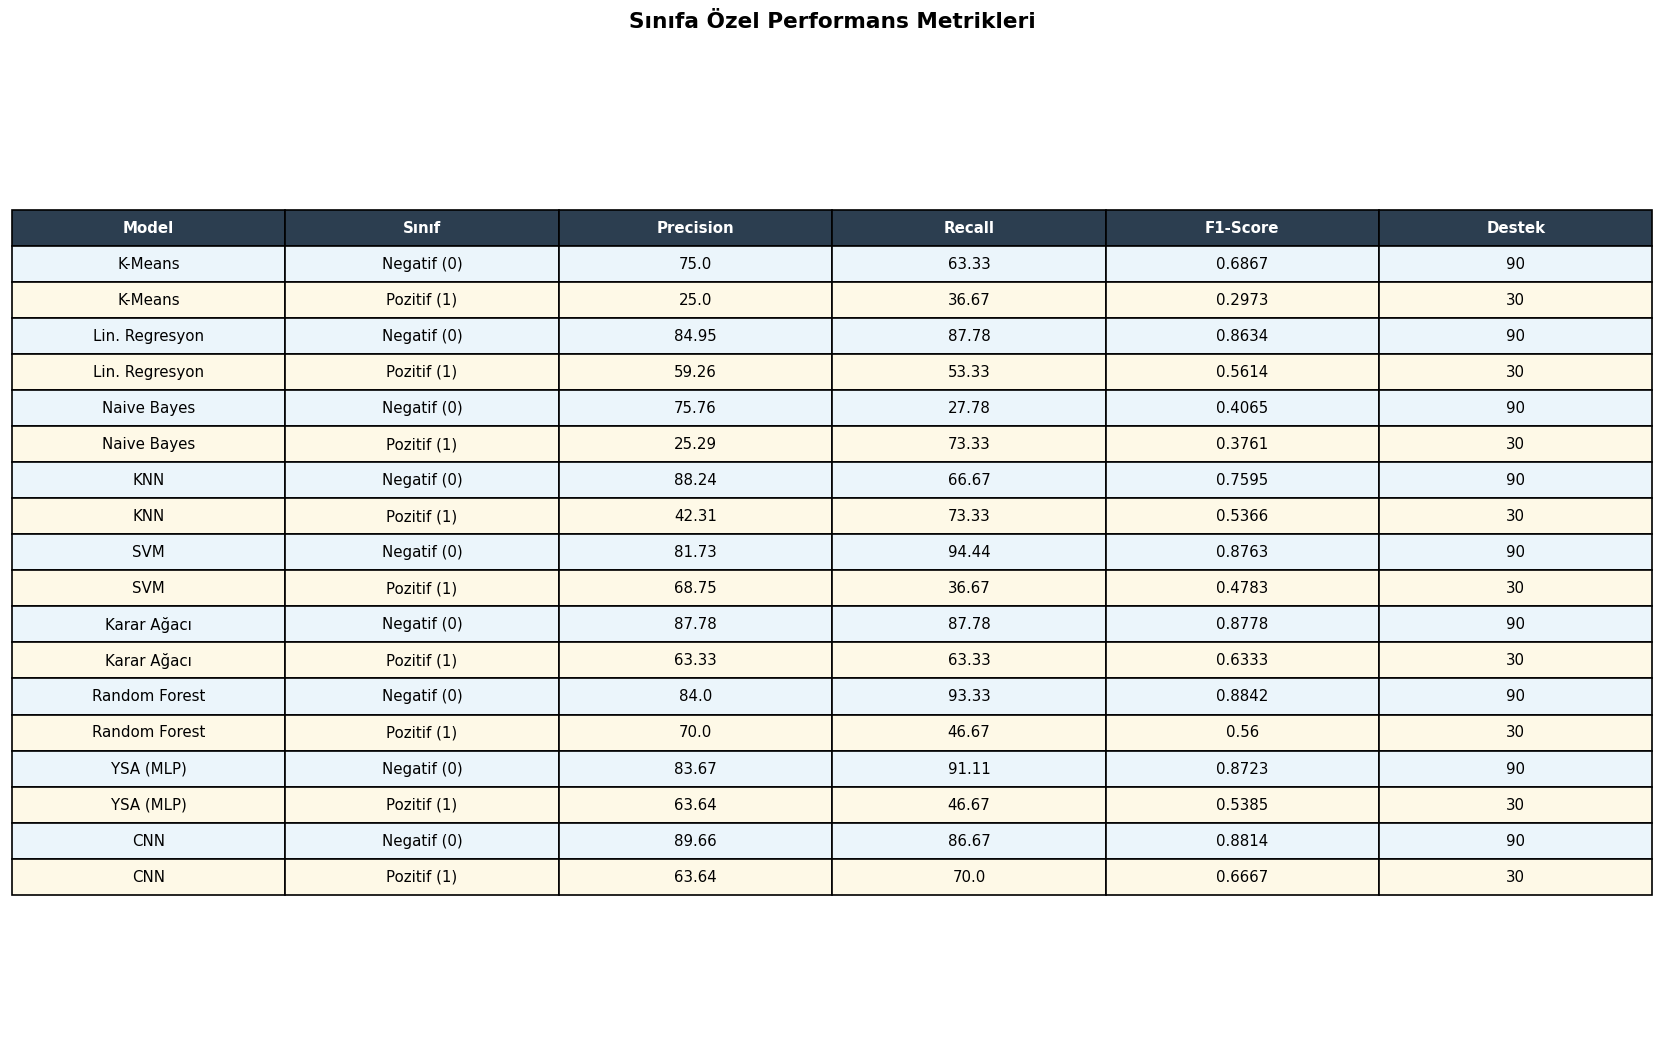

In [ ]:
satirlar2 = []
for isim, res in sonuclar.items():
    report = classification_report(y_test, res['y_pred'], output_dict=True, zero_division=0)
    for sinif in ['0', '1']:
        r = report.get(sinif, {})
        satirlar2.append({
            'Model': isim,
            'Sınıf': 'Negatif (0)' if sinif == '0' else 'Pozitif (1)',
            'Precision': round(r.get('precision', 0) * 100, 2),
            'Recall': round(r.get('recall', 0) * 100, 2),
            'F1-Score': round(r.get('f1-score', 0), 4),
            'Destek': int(r.get('support', 0))
        })

sinif_df = pd.DataFrame(satirlar2)

fig, ax = plt.subplots(figsize=(14, 9))
ax.axis('off')
sinif_data = sinif_df.values.tolist()
sinif_cols = list(sinif_df.columns)

tbl3 = ax.table(cellText=sinif_data, colLabels=sinif_cols, loc='center', cellLoc='center')
tbl3.auto_set_font_size(False)
tbl3.set_fontsize(9)
tbl3.scale(1, 1.5)

for j in range(len(sinif_cols)):
    tbl3[(0, j)].set_facecolor('#2C3E50')
    tbl3[(0, j)].set_text_props(color='white', fontweight='bold')

for i in range(1, len(sinif_data) + 1):
    if sinif_data[i-1][1] == 'Negatif (0)':
        bg = '#EBF5FB'
    else:
        bg = '#FEF9E7'
    for j in range(len(sinif_cols)):
        tbl3[(i, j)].set_facecolor(bg)

plt.title('Sınıfa Özel Performans Metrikleri', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [ ]:
def kategori(feat):
    if feat.startswith("Chi"):
        return "Bağlantı İndeksi"
    elif feat.startswith("fr_"):
        return "Fonksiyonel Grup"
    elif any(feat.startswith(p) for p in ["PEOE","EState","VSA_"]):
        return "Elektrostatik/VSA"
    elif feat in ["MolLogP","MolMR","TPSA","LabuteASA"]:
        return "Fizikokimyasal"
    elif feat in ["MolWt","ExactMolWt","HeavyAtomMolWt","HeavyAtomCount","NumValenceElectrons"]:
        return "Mol. Ağırlığı/Boyut"
    elif feat.startswith("Kappa"):
        return "Şekil İndeksi"
    elif any(k in feat for k in ["Ring","Aromatic","Aliphatic","Saturated"]):
        return "Halka/Yapısal"
    elif feat.startswith("Num"):
        return "Atom/Bağ Sayısı"
    elif feat in ["BalabanJ","BertzCT","Ipc","HallKierAlpha"]:
        return "Topoloji/Karmaşıklık"
    else:
        return "Diğer"

aciklamalar = {
    "BalabanJ":"Bağlantısallık İndeksi — Moleküler dallılık ve bağlantısallık",
    "BertzCT":"Bertz Karmaşıklık İndeksi — Yapısal karmaşıklık ölçütü",
    "Chi0":"0. Mertebe Bağlantı İndeksi — Atom sayısı bağımlı topoloji",
    "Chi0n":"0. Mertebe N. Bağlantı İndeksi — Valans normallanmış",
    "Chi0v":"0. Mertebe Valans Bağlantı İndeksi — Elektronegatiflik katkılı",
    "Chi1":"1. Mertebe Bağlantı İndeksi — Bağ topolojisi",
    "Chi1n":"1. Mertebe N. Bağlantı İndeksi",
    "Chi1v":"1. Mertebe Valans Bağlantı İndeksi",
    "Chi2n":"2. Mertebe N. Bağlantı İndeksi",
    "Chi2v":"2. Mertebe Valans Bağlantı İndeksi",
    "Chi3n":"3. Mertebe N. Bağlantı İndeksi",
    "Chi3v":"3. Mertebe Valans Bağlantı İndeksi",
    "Chi4n":"4. Mertebe N. Bağlantı İndeksi",
    "Chi4v":"4. Mertebe Valans Bağlantı İndeksi",
    "ExactMolWt":"Tam Molekül Ağırlığı (Da) — İzotop kütlesi",
    "MolWt":"Ortalama Molekül Ağırlığı (Da)",
    "MolLogP":"Lipofilisite (LogP) — Yağ/su bölüşüm katsayısı",
    "MolMR":"Molar Refraktivite — Polarizabilite ve hacim",
    "TPSA":"Topolojik Polar Yüzey Alanı (Å²) — Membran geçirgenlik göstergesi",
    "HeavyAtomCount":"Ağır Atom Sayısı (H hariç)",
    "HeavyAtomMolWt":"Ağır Atom Molekül Ağırlığı",
    "NumHAcceptors":"H-Bağı Akseptör Sayısı",
    "NumHDonors":"H-Bağı Donör Sayısı",
    "NumRotatableBonds":"Döndürülebilir Bağ Sayısı — Esneklik",
    "NumAromaticRings":"Aromatik Halka Sayısı",
    "NumHeteroatoms":"Heteroatom Sayısı (N, O, S vb.)",
    "RingCount":"Toplam Halka Sayısı",
    "FractionCSP3":"sp3 Karbon Oranı — Karmaşık yapı göstergesi",
    "HallKierAlpha":"Hall-Kier Alfa — Atom boyutu düzeltmesi",
    "Ipc":"Bilgi İçeriği (Ipc) — Graf tabanlı karmaşıklık",
    "Kappa1":"Kappa1 Şekil İndeksi — Lineer/dallı yapı",
    "Kappa2":"Kappa2 Şekil İndeksi — Halkalı yapı",
    "Kappa3":"Kappa3 Şekil İndeksi — 3D şekil yaklaşımı",
    "LabuteASA":"Labute Erişilebilir Yüzey Alanı (Å²)",
    "MaxAbsEStateIndex":"Maksimum Mutlak E-State İndeksi",
    "MaxEStateIndex":"Maksimum E-State İndeksi",
    "MinEStateIndex":"Minimum E-State İndeksi",
    "MaxPartialCharge":"Maksimum Kısmi Yük",
    "MinPartialCharge":"Minimum Kısmi Yük",
    "NOCount":"N ve O Atom Sayısı",
    "NHOHCount":"NH ve OH Grup Sayısı",
    "NumValenceElectrons":"Valans Elektron Sayısı",
    "fr_benzene":"Benzen Halkası Parça Sayısı",
    "fr_halogen":"Halojen Grubu Sayısı",
    "fr_ether":"Eter Grubu Sayısı",
    "fr_NH1":"Sekonder Amin (NH) Sayısı",
    "fr_NH0":"Tersiyer Amin (N) Sayısı",
    "fr_Ar_N":"Aromatik N Atom Sayısı",
    "fr_pyridine":"Piridin Halkası Sayısı",
    "fr_amide":"Amid Grubu Sayısı",
    "fr_aniline":"Anilin Grubu Sayısı",
}
print("Yardımcı fonksiyonlar tanımlandı.")

Yardımcı fonksiyonlar tanımlandı.


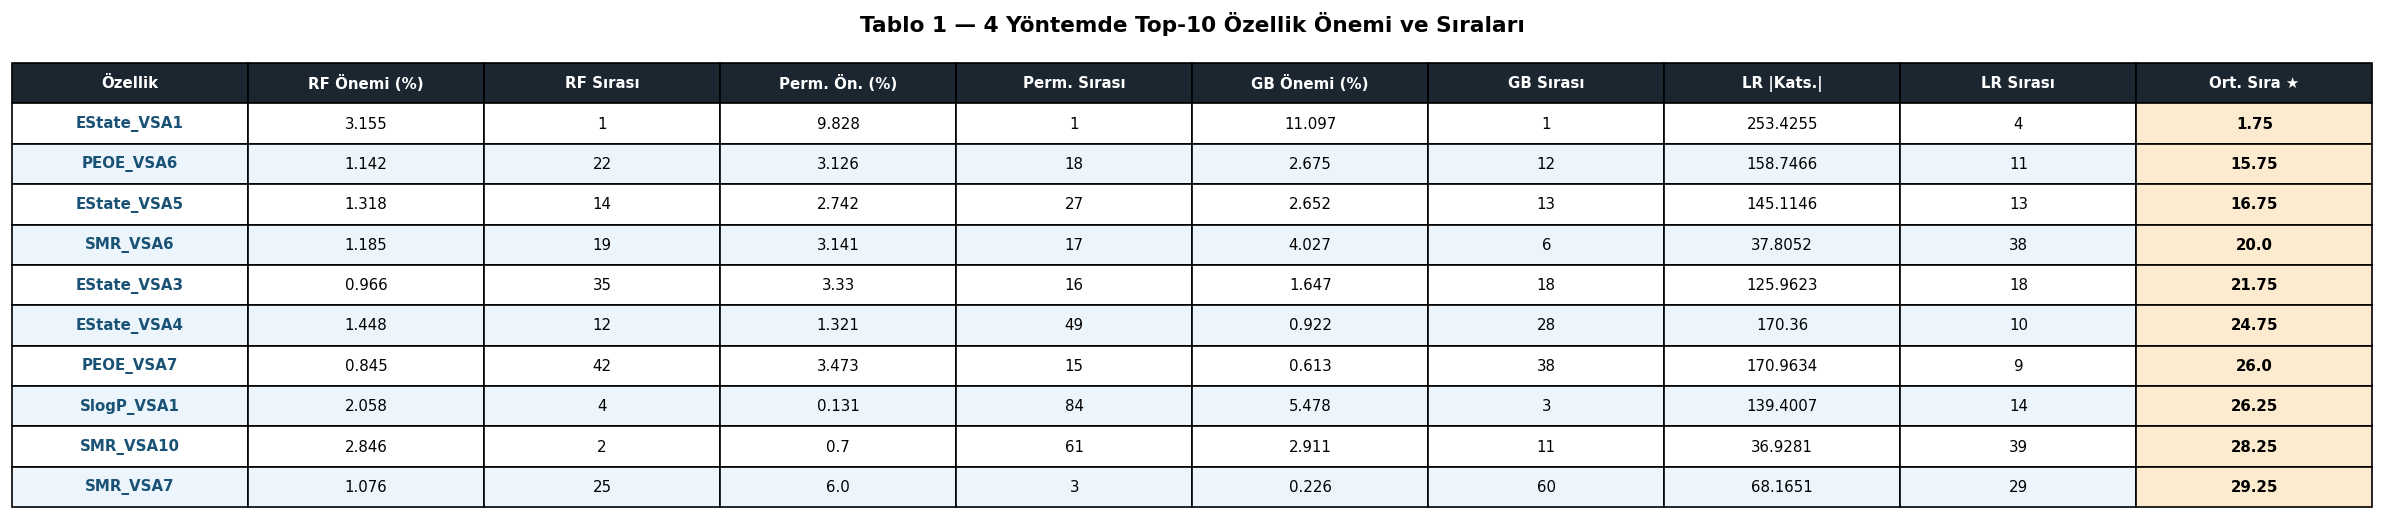

    Özellik  RF Önemi (%)  RF Sırası  Perm. Ön. (%)  Perm. Sırası  GB Önemi (%)  GB Sırası  LR |Kats.|  LR Sırası  Ort. Sıra ★
EState_VSA1         3.155          1          9.828             1        11.097          1    253.4255          4         1.75
  PEOE_VSA6         1.142         22          3.126            18         2.675         12    158.7466         11        15.75
EState_VSA5         1.318         14          2.742            27         2.652         13    145.1146         13        16.75
   SMR_VSA6         1.185         19          3.141            17         4.027          6     37.8052         38        20.00
EState_VSA3         0.966         35          3.330            16         1.647         18    125.9623         18        21.75
EState_VSA4         1.448         12          1.321            49         0.922         28    170.3600         10        24.75
  PEOE_VSA7         0.845         42          3.473            15         0.613         38    170.9634         

In [ ]:
rows = []
for feat in top10_features:
    rows.append({
        "Özellik":        feat,
        "RF Önemi (%)":   round(fi_rf[feat]*100, 3),
        "RF Sırası":      int(rank_rf[feat]),
        "Perm. Ön. (%)":  round(fi_perm[feat]*100, 3),
        "Perm. Sırası":   int(rank_perm[feat]),
        "GB Önemi (%)":   round(fi_gb[feat]*100, 3),
        "GB Sırası":      int(rank_gb[feat]),
        "LR |Kats.|":     round(fi_lr[feat], 4),
        "LR Sırası":      int(rank_lr[feat]),
        "Ort. Sıra ★":   round(top10_consensus[feat], 2),
    })
t1_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(20, 4.5))
ax.axis("off")
cols = list(t1_df.columns)
data = t1_df.values.tolist()
tbl = ax.table(cellText=data, colLabels=cols, loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.85)

for j in range(len(cols)):
    tbl[(0,j)].set_facecolor("#1B2631")
    tbl[(0,j)].set_text_props(color="white", fontweight="bold")
for i in range(1, len(data)+1):
    bg = "#EBF5FB" if i%2==0 else "white"
    for j in range(len(cols)):
        tbl[(i,j)].set_facecolor(bg)
    tbl[(i,0)].set_text_props(fontweight="bold", color="#1A5276")
    tbl[(i, len(cols) - 1)].set_facecolor("#FDEBD0")
    tbl[(i, len(cols) - 1)].set_text_props(fontweight="bold")

plt.title("Tablo 1 — 4 Yöntemde Top-10 Özellik Önemi ve Sıraları",
          fontsize=13, fontweight="bold", pad=16)
plt.tight_layout()
plt.show()
print(t1_df.to_string(index=False))


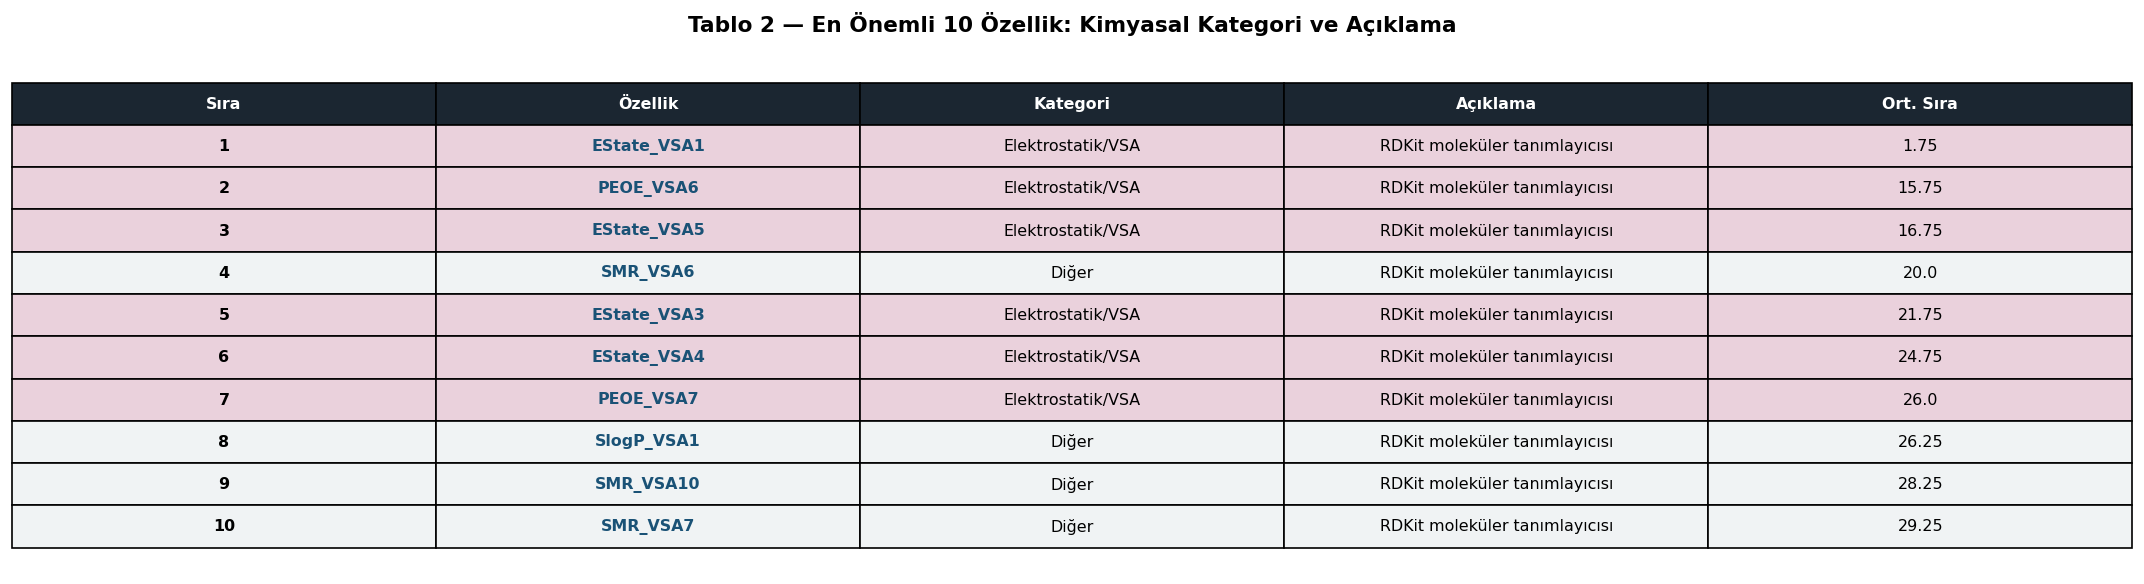

In [ ]:
cat_colors = {
    "Bağlantı İndeksi":"#D5F5E3","Fonksiyonel Grup":"#FDEBD0",
    "Elektrostatik/VSA":"#EAD1DC","Fizikokimyasal":"#D6EAF8",
    "Mol. Ağırlığı/Boyut":"#FEF9E7","Şekil İndeksi":"#E8DAEF",
    "Halka/Yapısal":"#FAD7A0","Atom/Bağ Sayısı":"#A9CCE3",
    "Topoloji/Karmaşıklık":"#F9E79F","Diğer":"#F0F3F4",
}
rows2 = []
for i, feat in enumerate(top10_features, 1):
    rows2.append({
        "Sıra": i, "Özellik": feat,
        "Kategori": kategori(feat),
        "Açıklama": aciklamalar.get(feat, "RDKit moleküler tanımlayıcısı"),
        "Ort. Sıra": round(top10_consensus[feat], 2),
    })
t2_df = pd.DataFrame(rows2)

fig, ax = plt.subplots(figsize=(18, 5))
ax.axis("off")
cols2 = list(t2_df.columns)
data2 = t2_df.values.tolist()
tbl2 = ax.table(cellText=data2, colLabels=cols2, loc="center", cellLoc="center")
tbl2.auto_set_font_size(False)
tbl2.set_fontsize(9.5)
tbl2.scale(1, 1.9)

for j in range(len(cols2)):
    tbl2[(0,j)].set_facecolor("#1B2631")
    tbl2[(0,j)].set_text_props(color="white", fontweight="bold")
for i in range(1, len(data2)+1):
    bg = cat_colors.get(data2[i-1][2], "#F0F3F4")
    for j in range(len(cols2)):
        tbl2[(i,j)].set_facecolor(bg)
    tbl2[(i,0)].set_text_props(fontweight="bold")
    tbl2[(i,1)].set_text_props(fontweight="bold", color="#1A5276")

plt.title("Tablo 2 — En Önemli 10 Özellik: Kimyasal Kategori ve Açıklama",
          fontsize=13, fontweight="bold", pad=16)
plt.tight_layout()
plt.show()

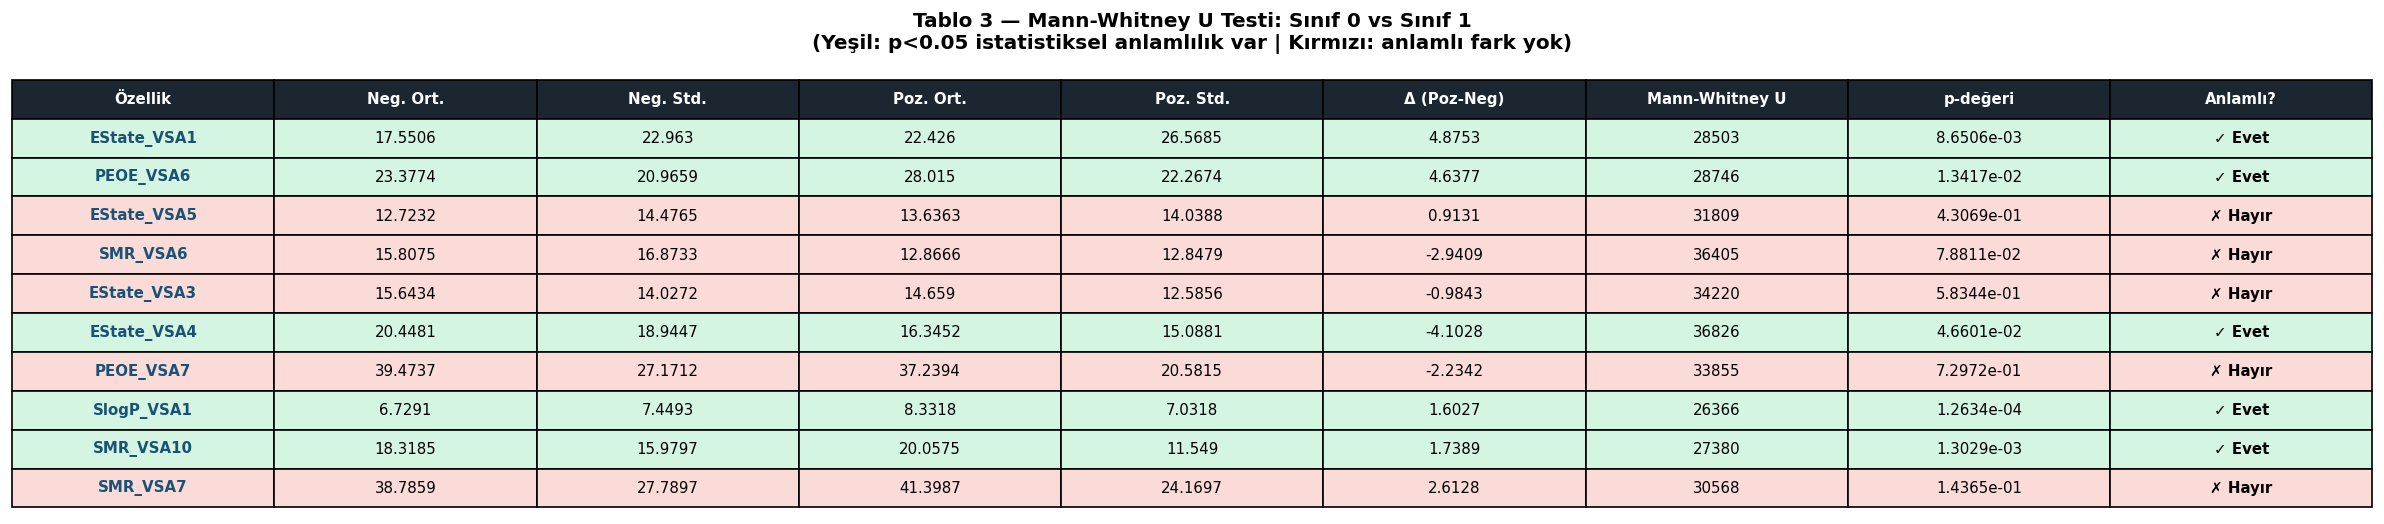

    Özellik  Neg. Ort.  Neg. Std.  Poz. Ort.  Poz. Std.  Δ (Poz-Neg)  Mann-Whitney U   p-değeri Anlamlı?
EState_VSA1    17.5506    22.9630    22.4260    26.5685       4.8753           28503 8.6506e-03   ✓ Evet
  PEOE_VSA6    23.3774    20.9659    28.0150    22.2674       4.6377           28746 1.3417e-02   ✓ Evet
EState_VSA5    12.7232    14.4765    13.6363    14.0388       0.9131           31809 4.3069e-01  ✗ Hayır
   SMR_VSA6    15.8075    16.8733    12.8666    12.8479      -2.9409           36405 7.8811e-02  ✗ Hayır
EState_VSA3    15.6434    14.0272    14.6590    12.5856      -0.9843           34220 5.8344e-01  ✗ Hayır
EState_VSA4    20.4481    18.9447    16.3452    15.0881      -4.1028           36826 4.6601e-02   ✓ Evet
  PEOE_VSA7    39.4737    27.1712    37.2394    20.5815      -2.2342           33855 7.2972e-01  ✗ Hayır
 SlogP_VSA1     6.7291     7.4493     8.3318     7.0318       1.6027           26366 1.2634e-04   ✓ Evet
  SMR_VSA10    18.3185    15.9797    20.0575    11.5490

In [ ]:
import scipy.stats as stats
X_all = pd.concat([X_train_orig, X_test], ignore_index=True)
y_all = pd.concat([y_train_orig, y_test], ignore_index=True)

rows3 = []
for feat in top10_features:
    d0 = X_all.loc[y_all==0, feat]
    d1 = X_all.loc[y_all==1, feat]
    u_stat, p_val = stats.mannwhitneyu(d0, d1, alternative="two-sided")
    rows3.append({
        "Özellik":         feat,
        "Neg. Ort.":       round(d0.mean(), 4),
        "Neg. Std.":       round(d0.std(),  4),
        "Poz. Ort.":       round(d1.mean(), 4),
        "Poz. Std.":       round(d1.std(),  4),
        "Δ (Poz-Neg)":     round(d1.mean()-d0.mean(), 4),
        "Mann-Whitney U":  int(u_stat),
        "p-değeri":        f"{p_val:.4e}",
        "Anlamlı?":        "✓ Evet" if p_val < 0.05 else "✗ Hayır",
    })
t3_df = pd.DataFrame(rows3)

fig, ax = plt.subplots(figsize=(20, 4.5))
ax.axis("off")
cols3 = list(t3_df.columns)
data3 = t3_df.values.tolist()
tbl3 = ax.table(cellText=data3, colLabels=cols3, loc="center", cellLoc="center")
tbl3.auto_set_font_size(False)
tbl3.set_fontsize(9)
tbl3.scale(1, 1.85)

for j in range(len(cols3)):
    tbl3[(0,j)].set_facecolor("#1B2631")
    tbl3[(0,j)].set_text_props(color="white", fontweight="bold")
for i in range(1, len(data3)+1):
    bg = "#D5F5E3" if "Evet" in str(data3[i-1][-1]) else "#FADBD8"
    for j in range(len(cols3)):
        tbl3[(i,j)].set_facecolor(bg)
    tbl3[(i,0)].set_text_props(fontweight="bold", color="#1A5276")
    tbl3[(i,len(cols3)-1)].set_text_props(fontweight="bold")

plt.title("Tablo 3 — Mann-Whitney U Testi: Sınıf 0 vs Sınıf 1\n"
          "(Yeşil: p<0.05 istatistiksel anlamlılık var | Kırmızı: anlamlı fark yok)",
          fontsize=12, fontweight="bold", pad=16)
plt.tight_layout()
plt.show()
print(t3_df.to_string(index=False))

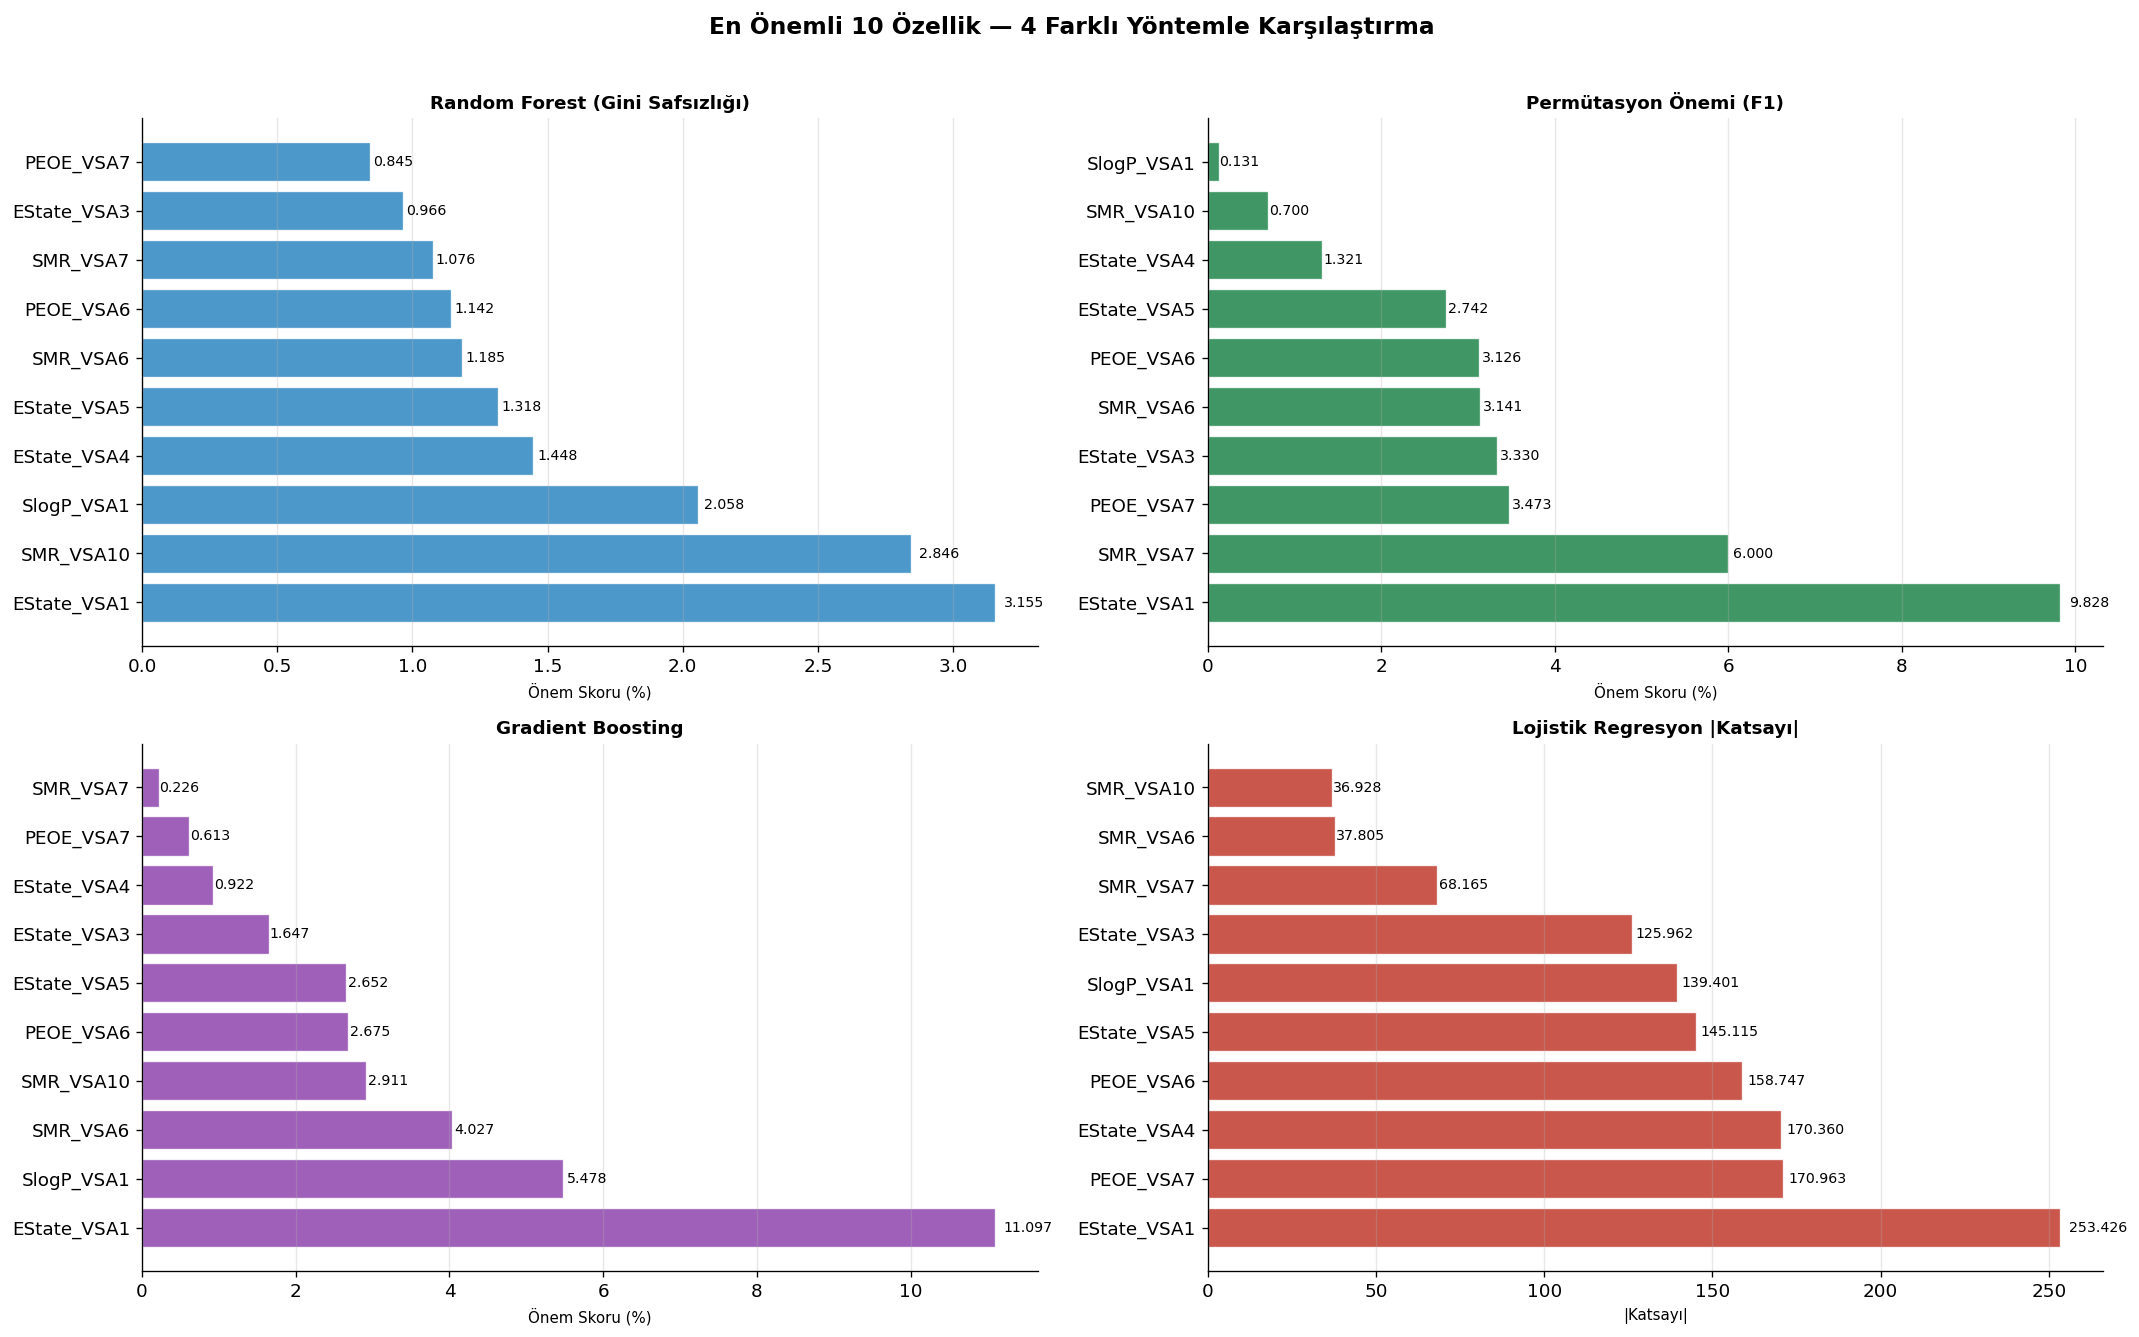

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 11))
configs = [
    (top_rf,   "#2E86C1", "Random Forest (Gini Safsızlığı)", "Önem Skoru (%)"),
    (top_perm, "#1E8449", "Permütasyon Önemi (F1)",          "Önem Skoru (%)"),
    (top_gb,   "#8E44AD", "Gradient Boosting",               "Önem Skoru (%)"),
    (top_lr,   "#C0392B", "Lojistik Regresyon |Katsayı|",   "|Katsayı|"),
]
for ax, (top, color, title, xlabel) in zip(axes.flatten(), configs):
    feats = list(top.index)[::-1]
    vals  = list(top.values)[::-1]
    if title != "Lojistik Regresyon |Katsayı|":
        vals = [v*100 for v in vals]
    bars = ax.barh(feats, vals, color=color, alpha=0.85, edgecolor="white", linewidth=0.8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=8.5)
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.grid(axis="x", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("En Önemli 10 Özellik — 4 Farklı Yöntemle Karşılaştırma",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

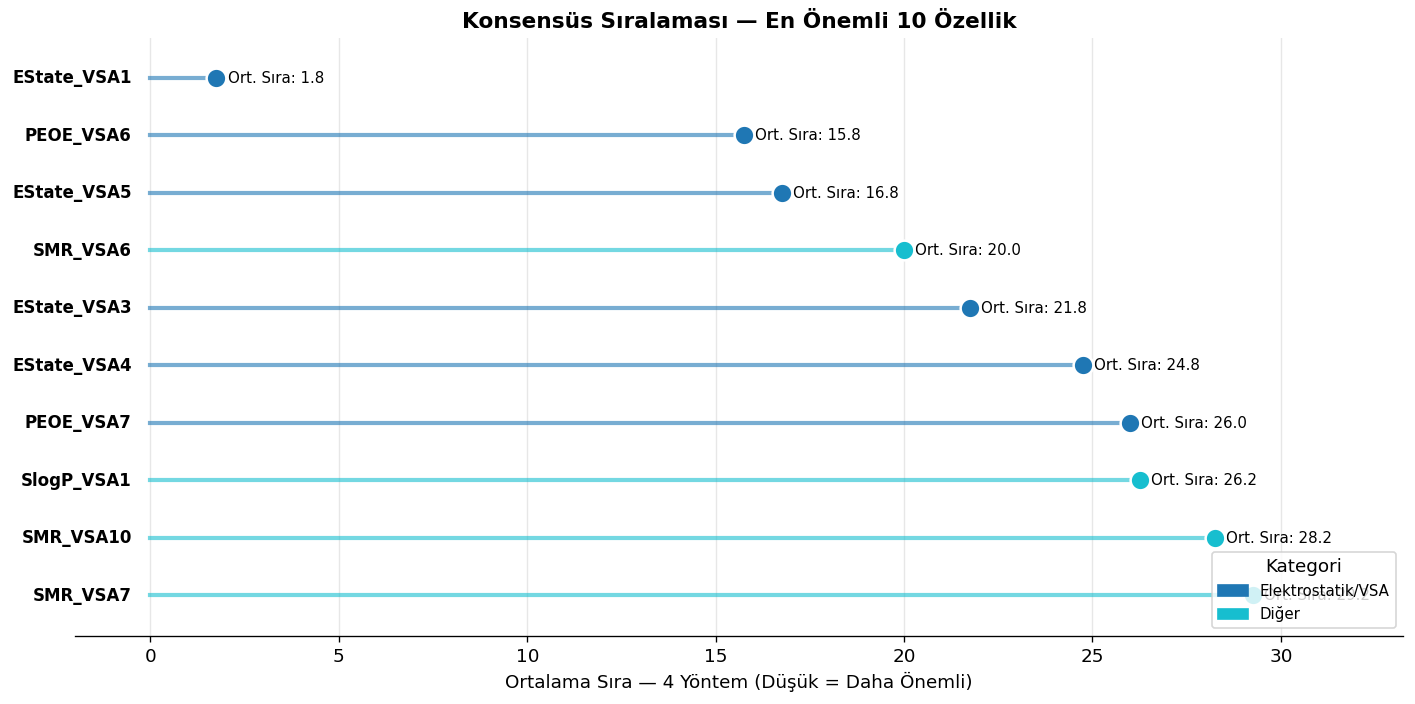

In [ ]:
import matplotlib.patches as mpatches

feats_rev = top10_features[::-1]
ranks_rev = [top10_consensus[f] for f in feats_rev]
cats_rev  = [kategori(f) for f in feats_rev]

unique_cats = list(dict.fromkeys([kategori(f) for f in top10_features]))
cmap = plt.cm.get_cmap("tab10", len(unique_cats))
cat_cmap = {c: cmap(i) for i, c in enumerate(unique_cats)}
colors_rev = [cat_cmap[c] for c in cats_rev]

fig, ax = plt.subplots(figsize=(12, 6))
for i, (feat, rank, col) in enumerate(zip(feats_rev, ranks_rev, colors_rev)):
    ax.plot([0, rank], [i, i], color=col, linewidth=2.5, alpha=0.6)
    ax.scatter(rank, i, color=col, s=140, zorder=5, edgecolors="white", linewidths=1.5)
    ax.text(-0.5, i, feat, ha="right", va="center", fontsize=10, fontweight="bold")
    ax.text(rank+0.3, i, f"Ort. Sıra: {rank:.1f}", va="center", fontsize=9)

ax.set_xlim(-2, max(ranks_rev)+4)
ax.set_ylim(-0.7, len(feats_rev)-0.3)
ax.set_xlabel("Ortalama Sıra — 4 Yöntem (Düşük = Daha Önemli)", fontsize=11)
ax.set_title("Konsensüs Sıralaması — En Önemli 10 Özellik", fontsize=13, fontweight="bold")
ax.yaxis.set_visible(False)
for sp in ["left","top","right"]:
    ax.spines[sp].set_visible(False)
ax.grid(axis="x", alpha=0.3)

patches = [mpatches.Patch(color=cat_cmap[c], label=c) for c in unique_cats
           if any(kategori(f)==c for f in top10_features)]
ax.legend(handles=patches, loc="lower right", fontsize=9, title="Kategori")
plt.tight_layout()
plt.show()

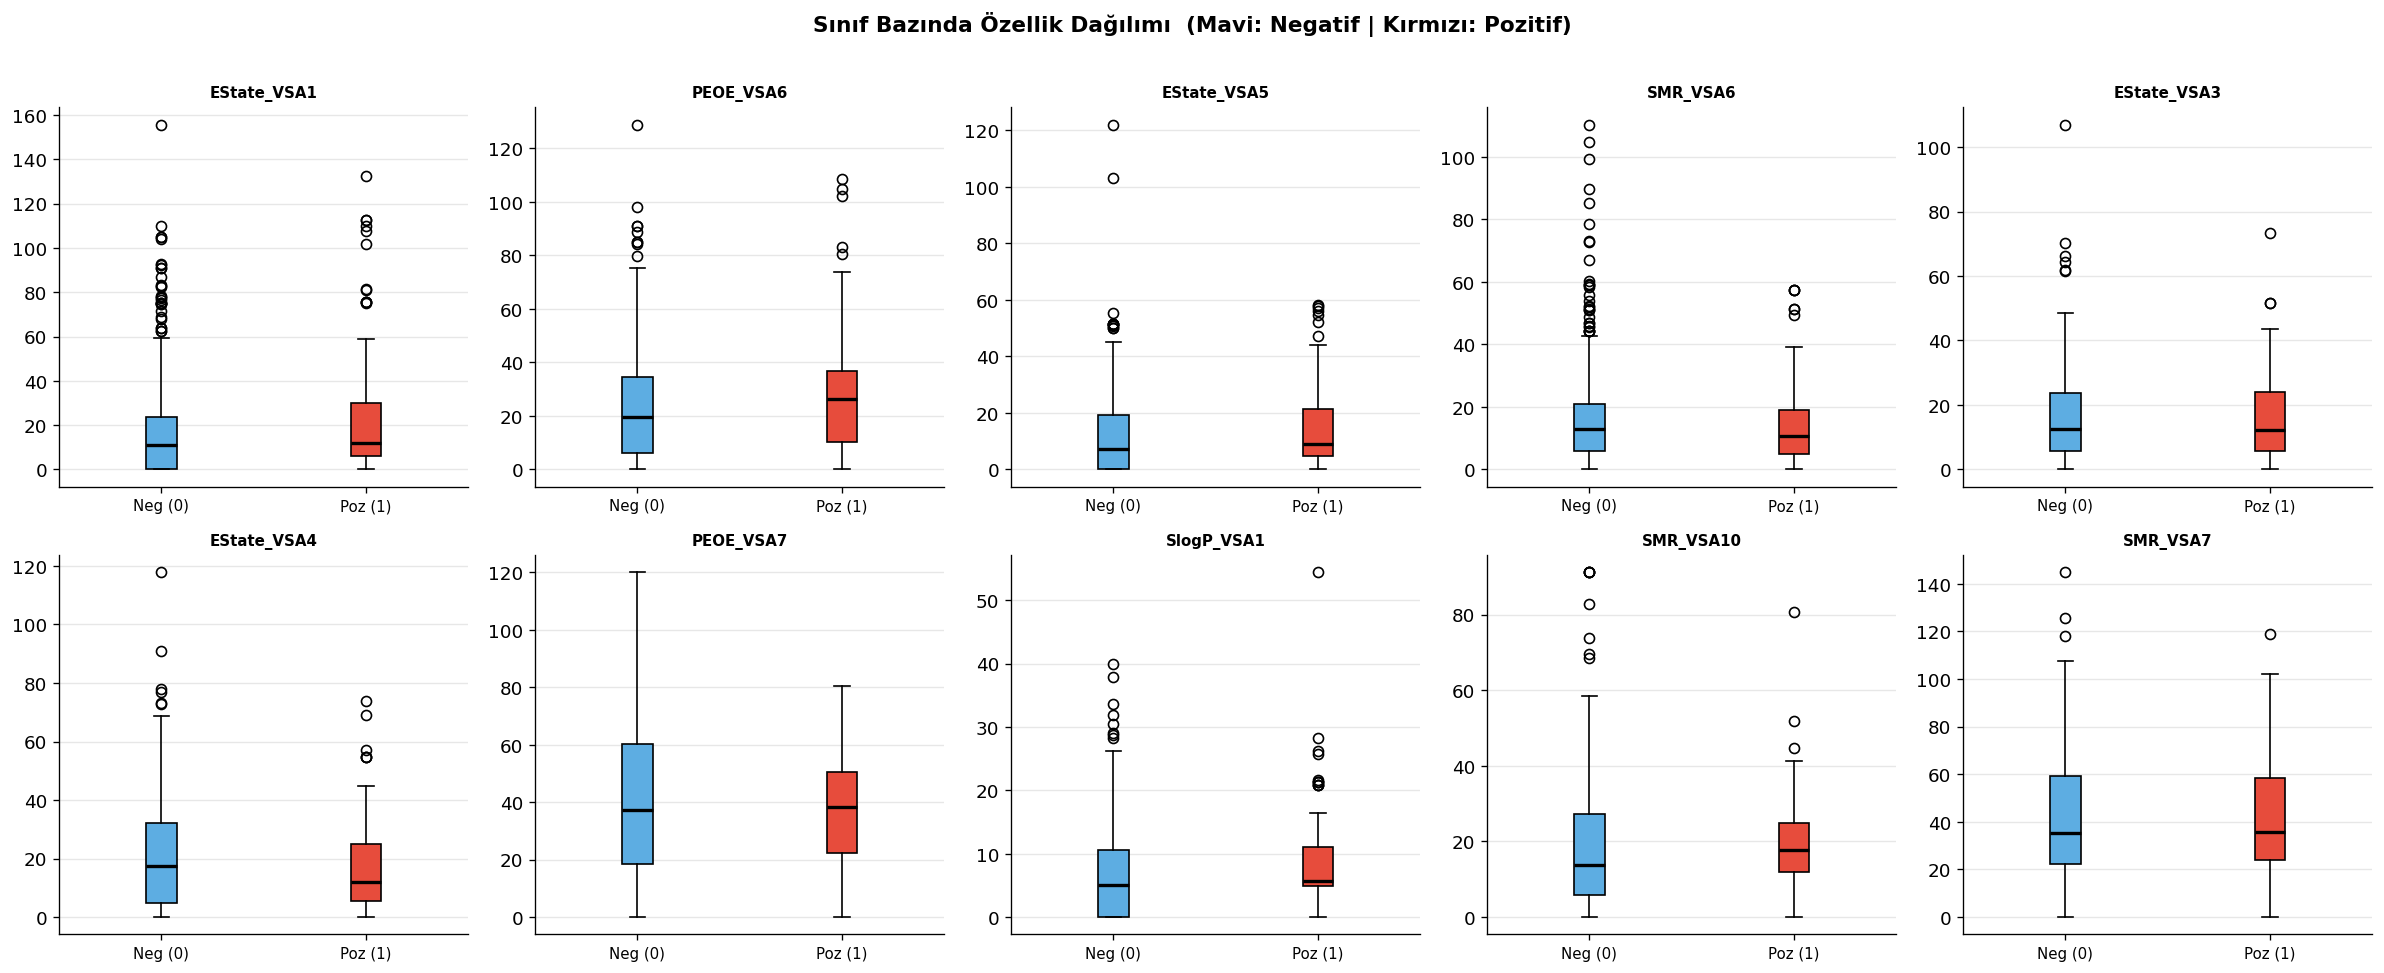

In [ ]:
X_all = pd.concat([X_train_orig, X_test], ignore_index=True)
y_all = pd.concat([y_train_orig, y_test], ignore_index=True)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, feat in zip(axes.flatten(), top10_features):
    d0 = X_all.loc[y_all==0, feat]
    d1 = X_all.loc[y_all==1, feat]
    bp = ax.boxplot([d0, d1], patch_artist=True,
                    medianprops=dict(color="black", linewidth=2))
    bp["boxes"][0].set_facecolor("#5DADE2")
    bp["boxes"][1].set_facecolor("#E74C3C")
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Neg (0)", "Poz (1)"], fontsize=9)
    ax.set_title(feat, fontweight="bold", fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Sınıf Bazında Özellik Dağılımı  (Mavi: Negatif | Kırmızı: Pozitif)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

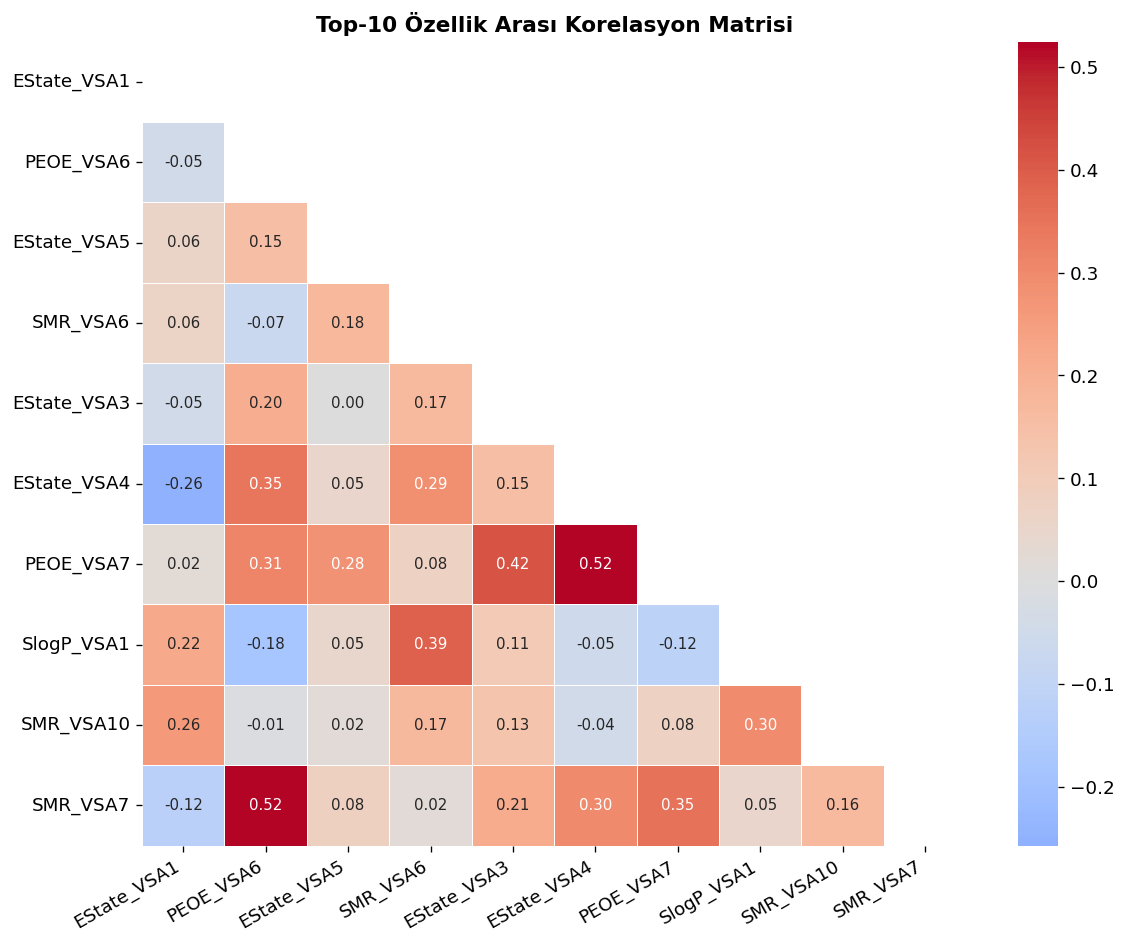

In [ ]:
corr = X_all[top10_features].corr()
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            mask=mask, ax=ax, linewidths=0.5, linecolor="white",
            annot_kws={"size": 9})
ax.set_title("Top-10 Özellik Arası Korelasyon Matrisi", fontsize=13, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 60)
print("ÖZET — En Önemli 10 Kimyasal Özellik (Konsensüs)")
print("=" * 60)
for i, feat in enumerate(top10_features, 1):
    print(f"  {i:2d}. {feat:<30} [{kategori(feat)}]")
print()
print("Kullanılan yöntemler:")
print("  1. Random Forest Gini Safsızlığı")
print("  2. Permütasyon Önemi (test seti, F1 metriği)")
print("  3. Gradient Boosting Önemi")
print("  4. Lojistik Regresyon |Katsayı|")
print()
print("İstatistiksel test: Mann-Whitney U (parametrik olmayan)")
print("=" * 60)

ÖZET — En Önemli 10 Kimyasal Özellik (Konsensüs)
   1. EState_VSA1                    [Elektrostatik/VSA]
   2. PEOE_VSA6                      [Elektrostatik/VSA]
   3. EState_VSA5                    [Elektrostatik/VSA]
   4. SMR_VSA6                       [Diğer]
   5. EState_VSA3                    [Elektrostatik/VSA]
   6. EState_VSA4                    [Elektrostatik/VSA]
   7. PEOE_VSA7                      [Elektrostatik/VSA]
   8. SlogP_VSA1                     [Diğer]
   9. SMR_VSA10                      [Diğer]
  10. SMR_VSA7                       [Diğer]

Kullanılan yöntemler:
  1. Random Forest Gini Safsızlığı
  2. Permütasyon Önemi (test seti, F1 metriği)
  3. Gradient Boosting Önemi
  4. Lojistik Regresyon |Katsayı|

İstatistiksel test: Mann-Whitney U (parametrik olmayan)


In [ ]:
# Pipeline ve Model Optimizasyonu
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Pipeline (SMOTE varsa önceki hücrede uygulanmış varsayılıyor)
pipeline = Pipeline([
    ('model', RandomForestClassifier(random_state=42))
])

# Parametre grid
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20]
}

# Grid Search
grid = GridSearchCV(pipeline, param_grid, cv=3, n_jobs=-1)
grid.fit(X_train_scaled, y_train_bal)

print('En iyi parametreler:', grid.best_params_)
print('En iyi skor:', grid.best_score_)

En iyi parametreler: {'model__max_depth': None, 'model__n_estimators': 100}
En iyi skor: 0.8776266852626685
